# Why NBA Predictive Models Fail to Beat Vegas Lines
**Hidden variance, market efficiency, and the limits of public-signal models**

**Question.** Can machine-learning models predict NBA game outcomes or spreads
better than the Vegas closing line, and if not, why?

**Thesis (deliberately modest).** Models can predict *who wins* about as well as
published work, but the remaining edge against the closing line is too small and
too noisy to beat the market after the vig.

This notebook loads features built in DuckDB (rolling team form, rest, Elo - all
strictly pre-game to avoid look-ahead bias), trains three model families with a
*time-aware* split, and judges them not on raw accuracy but on whether they
produce any edge against the line.

In [1]:
import sys; from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
import numpy as np, pandas as pd, duckdb
from scipy.stats import norm
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, roc_auc_score, brier_score_loss,
                             log_loss, mean_absolute_error)
from sklearn.calibration import calibration_curve
from xgboost import XGBClassifier, XGBRegressor
import matplotlib.pyplot as plt
import config

con = duckdb.connect(str(config.DB_PATH), read_only=True)
df = con.execute('''SELECT * FROM model_data
    WHERE h_prior>=10 AND a_prior>=10 AND home_covered IS NOT NULL''').df()
for col in ("h_b2b","a_b2b"): df[col] = df[col].astype(int)
print(df.shape)
df[["season","home_abbr","away_abbr","d_elo","home_spread","home_margin","home_covered"]].head()

(11339, 41)


,season,home_abbr,away_abbr,d_elo,home_spread,home_margin,home_covered
0,2015-16,SAC,TOR,-81.896038,2.0,6,1
1,2015-16,PHI,DAL,-102.477029,8.0,-6,1
2,2015-16,MEM,OKC,-7.946452,-2.5,8,1
3,2015-16,BKN,ATL,-83.072085,4.5,2,1
4,2015-16,DET,CLE,-47.211094,4.5,5,1


## Features and the leakage rule
Every feature is computed from games that finished **before** tip-off: rolling
10-game form (SQL window frame `10 PRECEDING .. 1 PRECEDING`), rest days, and a
sequential Elo. The betting line (spread/total/moneyline) is **never** a model
input - otherwise the model would just read back the market's own answer. The
line is kept only as the benchmark to beat.

In [2]:
FEATURES = ["d_elo","d_margin","d_off","d_def","d_efg","d_winpct","d_rest",
    "home_elo_pre","away_elo_pre","h_off","h_def","h_winpct","h_pace","h_rest",
    "a_off","a_def","a_winpct","a_pace","a_rest"]
df = df.dropna(subset=FEATURES+["home_win","home_margin","home_spread"])
TEST = ("2024-25","2025-26")
train, test = df[~df.season.isin(TEST)], df[df.season.isin(TEST)]
Xtr, Xte = train[FEATURES], test[FEATURES]
print(f"train {len(train)} games | test {len(test)} games {sorted(test.season.unique())}")

train 9205 games | test 2134 games ['2024-25', '2025-26']


## 1. Predicting the winner
Logistic regression and XGBoost vs. the Vegas-implied probability (derived from
the spread, since moneylines are missing in recent seasons of this dataset:
margin ~ Normal(-spread, sigma), so P(home win) = P(margin > 0)).

In [3]:
ytr, yte = train.home_win.astype(int), test.home_win.astype(int)
logit = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(Xtr, ytr)
xgbc = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, eval_metric="logloss").fit(Xtr, ytr)
p_logit, p_xgb = logit.predict_proba(Xte)[:,1], xgbc.predict_proba(Xte)[:,1]
sigma = float(train.home_margin.std())
p_vegas = norm.cdf(-test.home_spread.values / sigma)

rows = []
for name, p in [("logistic",p_logit),("xgboost",p_xgb),("vegas (spread)",p_vegas)]:
    rows.append({"model":name, "accuracy":accuracy_score(yte,p>0.5),
                 "roc_auc":roc_auc_score(yte,p), "brier":brier_score_loss(yte,p),
                 "log_loss":log_loss(yte,p)})
pd.DataFrame(rows).round(4)

,model,accuracy,roc_auc,brier,log_loss
0,logistic,0.6790,0.7323,0.2079,0.6031
1,xgboost,0.6523,0.7145,0.2137,0.6157
2,vegas (spread),0.6982,0.7639,0.1963,0.5757


Our models reach roughly **68%** accuracy - in line with the Stanford CS229
study - but the **Vegas line is more accurate and better calibrated on every
metric**. The market already contains our signal and more.

## 2. Predicting the margin

In [4]:
mtr, mte = train.home_margin, test.home_margin
lin = make_pipeline(StandardScaler(), LinearRegression()).fit(Xtr, mtr)
xgbr = XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8).fit(Xtr, mtr)
vegas_margin = -test.home_spread.values
pd.DataFrame([
    {"model":"linear","mae":mean_absolute_error(mte, lin.predict(Xte))},
    {"model":"xgboost","mae":mean_absolute_error(mte, xgbr.predict(Xte))},
    {"model":"vegas line","mae":mean_absolute_error(mte, vegas_margin)},
]).round(3)

,model,mae
0,linear,11.322
1,xgboost,11.511
2,vegas line,10.787


## 3. The real question: against the spread
A model only has value if it beats the closing line. We bet the home team to
cover when the model's predicted margin exceeds the line, and score every bet at
the standard -110 vig (**52.4% = breakeven**).

In [5]:
VIG = 100/110
def ats(name, pick_home, sub):
    cov = sub.home_covered.values
    win = np.where(pick_home, cov==1, cov==0)
    return {"strategy":name, "bets":len(sub), "ats_hit_%":round(100*win.mean(),2),
            "roi_%":round(100*(win*VIG-(~win)).mean(),2)}
spread = test.home_spread.values
m_lin, m_xgb = lin.predict(Xte), xgbr.predict(Xte)
edge = m_xgb - (-spread); sel = np.abs(edge) >= 3
res = pd.DataFrame([
    ats("linear vs spread", m_lin > -spread, test),
    ats("xgboost vs spread", m_xgb > -spread, test),
    ats("elo favorite", test.d_elo.values > 0, test),
    ats("always home", np.ones(len(test),bool), test),
    ats(f"xgboost edge>=3pts", (edge>0)[sel], test[sel]),
])
res

,strategy,bets,ats_hit_%,roi_%
0,linear vs spread,2134,49.16,-6.16
1,xgboost vs spread,2134,49.25,-5.98
2,elo favorite,2134,50.89,-2.85
3,always home,2134,50.47,-3.65
4,xgboost edge>=3pts,1064,49.06,-6.34


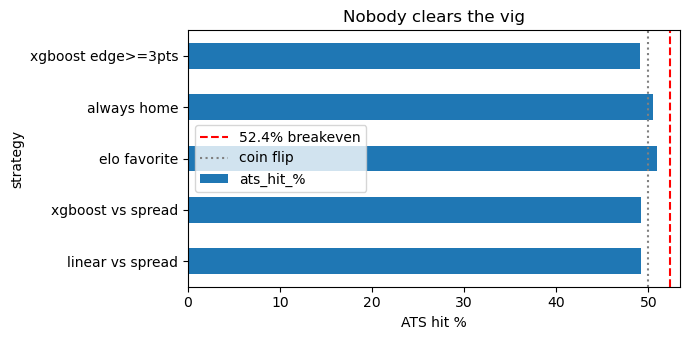

In [6]:
ax = res.set_index("strategy")["ats_hit_%"].plot(kind="barh", figsize=(7,3.5))
ax.axvline(52.4, color="red", ls="--", label="52.4% breakeven")
ax.axvline(50, color="gray", ls=":", label="coin flip")
ax.set_xlabel("ATS hit %"); ax.set_title("Nobody clears the vig"); ax.legend()
plt.tight_layout(); plt.show()

Every strategy lands **below breakeven with negative ROI**, and betting only
the "high-edge" games makes it *worse* - the model's apparent edge is noise.

## 4. Calibration: model vs market

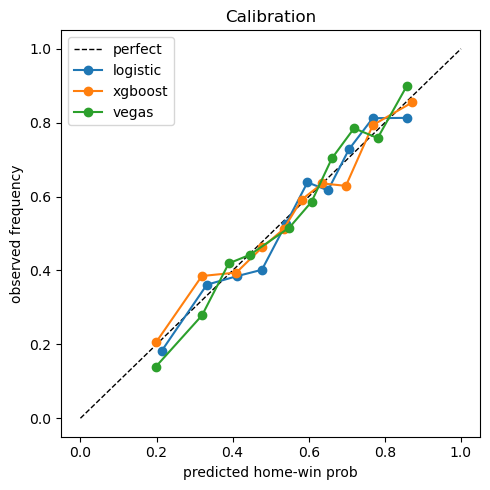

In [7]:
plt.figure(figsize=(5,5)); plt.plot([0,1],[0,1],"k--",lw=1,label="perfect")
for name,p in [("logistic",p_logit),("xgboost",p_xgb),("vegas",p_vegas)]:
    fp, mp = calibration_curve(yte, p, n_bins=10, strategy="quantile")
    plt.plot(mp, fp, marker="o", label=name)
plt.xlabel("predicted home-win prob"); plt.ylabel("observed frequency")
plt.title("Calibration"); plt.legend(); plt.tight_layout(); plt.show()

## Conclusion
Machine-learning models built on public box-score signal can predict NBA winners
about as well as published academic work (~68%), **but they do not beat the Vegas
closing line** - the line is more accurate, better calibrated, and no spread
strategy clears the vig. The efficient-market reading holds: by tip-off the
closing line already reflects the available signal, and what remains is hidden
variance (injuries, rotations, shooting noise) that a pre-game model cannot see.

*Honest takeaway: the value here is the rigorous evaluation - time-aware
validation, calibration, and profit simulation - not a betting edge.*